# Изучение рынка заведений общественного питания Москвы

- Автор: Никоноров Алексей
- Дата: 02.07.2026

### Цели и задачи проекта

Исследовательский анализ рынка общественного питания Москвы.
Цель — оценить рынок общепита Москвы и выявить перспективные ниши и локации для нового заведения. Задача — сформировать аналитическую базу для выбора формата, места и стратегии выхода на рынок.

### Описание данных

Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:
- `id` - id заведения;
- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — `5.0`);
- `chain` — число, выраженное `0` или `1`, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
`0` — заведение не является сетевым;
`1` — заведение является сетевым.
- `seats` — количество посадочных мест.

Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:
- `id` - id заведения;
- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
«Средний счёт: 1000–1500 ₽»;
«Цена чашки капучино: 130–220 ₽»;
«Цена бокала пива: 400–600 ₽».
и так далее;
- `middle_avg_bil` — число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»:
Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино»:
Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

### Содержимое проекта

 1. [Загрузка данных и знакомство с ними](#1razd)
 2. [Предобработка данных](#2razd)
 3. [Исследовательский анализ данных](#3razd)
 4. [Итоговый вывод и рекомендации](#4razd)

<a id='1razd'></a>
## 1. Загрузка данных и знакомство с ними

- Загрузим данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [1]:
# импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
!pip install phik
from phik import phik_matrix

In [2]:
# выгружаем данные в переменную rest_df
rest_df = pd.read_csv('/datasets/rest_info.csv')

In [3]:
# выгружаем данные в переменную price_df
price_df = pd.read_csv('/datasets/rest_price.csv')

- Познакомимся с данными и изучим общую информацию о них.

In [4]:
# выгружаем первые строки датафрейма rest_df
rest_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
# Выводим информацию о датафрейме rest_df
rest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [6]:
# выгружаем первые строки датафрейма price_df
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
# Выводим информацию о датафрейме price_df
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---

### Промежуточный вывод

Объем данных - 
`rest_df`: 8 406 строк и 9 столбцов с информацией о заведениях общепита.
`price_df`: 4 058 строк и 5 столбцов с ценовой информацией.

- Данные полностью соответствуют заявленному описанию. 
- Датафрейм `rest_df` содержит пропуски в столбцах `hours` и `seats`. 
- В `price_df` столбцы `price`, `avg_bill` содержат пропуска; 
- `middle_avg_bill` и `middle_coffee_cup` действительно содержат числа только при определённых формулировках в `avg_bill`, в остальных случаях — пропуски. Это не ошибка, а особенность расчёта метрик.
- Датафрейм `rest_df`: тип данных для столбца `chain` можно оптимизировать с понижением размерности, `seats` после обработки пропусков превести к типу `int`; датафрейм `price_df`: `price` позже имеет смысл перевести в тип `category` — это сэкономит память и упростит группировку.
- Число строк в `price_df` примерно в 2 раза меньше, чем в `rest_df` — не для всех заведений есть данные о ценах. При объединении по `id` часть строк из `rest_df` останется без ценовой информации (будут пропуски).

### Подготовка единого датафрейма

- Объединим данные двух датасетов в один, с которым продолжим работу.

In [8]:
# объединим два датафрейма в один 
df = pd.merge(rest_df, price_df, on='id', how='left')

In [9]:
# выведем первые 5 строк объединенного датафрейма
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [10]:
# выведем информацию об объединенном датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


<a id='2razd'></a>
## 2. Предобработка данных

Подготовим данные к исследовательскому анализу:

- Изучим корректность типов данных и при необходимости проведем их преобразование.

In [11]:
# преобразуем тип данных столбца chain
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

In [12]:
# поменяем тип данных столбца price 
df['price'] = df['price'].astype('category')

In [13]:
# поменяем тип данных столбца seats на целочисленный Int с сохранением пропусков
df['seats'] = df['seats'].astype('Int64')

- Изучим пропущенные значения в данных: посчитаем их количество в каждом столбце датафрейма, изучим данные с пропущенными значениями и предположим гипотезы их появления. Проведем обработку пропущенных значений.

In [14]:
# Количество пропусков в абсолютном значениие
missing_counts = df.isna().sum()
missing_counts

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [15]:
# количество пропусков в относительном значении
missing_pct = df.isna().mean() * 100
missing_pct

id                    0.000000
name                  0.000000
category              0.000000
address               0.000000
district              0.000000
hours                 6.376398
rating                0.000000
chain                 0.000000
seats                42.957411
price                60.563883
avg_bill             54.603854
middle_avg_bill      62.538663
middle_coffee_cup    93.635498
dtype: float64

- `hours` 536 пропусков, 6 % — пропуски могут быть из‑за технических сбоев при парсинге, либо у части заведений график не указан явно. Пропуски можно пометить как - `график не указан`.
- `middle_avg_bill` 5257 пропусков, 62% и `middle_coffee_cup` 7871 пропуск, 93% — здесь пропуски не случайны: метрики рассчитывались только тогда, когда в `avg_bill` была подходящая формулировка (например, «Средний счёт: 1500–1600 ₽» или «Цена чашки капучино:…»). Если формулировки не совпадали — расчёт не выполнялся. Это не ошибка, а особенность логики извлечения. На данном этапе оставляем как есть и при необходимости дальнейшего анализа по этим полям будет проведена дополнительная работа по частичному заполнению пропусков медианой столбцов `name` и `district`(Данный подход подразумевает, что у сетевых заведений в одном округе будет приблизительно равная цена и это позволит частично заполнить пропуски).
- `seats` 3611 пропусков, 43% - возможно, следствие несистемного сбора, поле могло быть опциональным, заполняться выборочно  или отсутствовать в исходных источниках данных. Оставим пропуски как есть и в дальнейшем анализе не будем их учитывать.
- `price` 5091 пропуск, 60% и `avg_bill` 4590 пропусков, 54% - отсутствие ценовой информации может быть связано с тем, что данные собирались из разных источников: где‑то цены есть, где‑то нет. В поле `price` создадим отдельную категорию `unknown` и заменим пропуски. Поскольку столбец `avg_bill` содержит множество разрозненных значений и привести их к какому-то универсальному значению не получится, оставляем пропуски, как есть.

In [16]:
# заменим пропуски в hours на 'график не указан'
df['hours'] = df['hours'].fillna('график не указан')

In [17]:
# создаем категорию unknown и заменяем все пропуски на unknown
df['price'] = df['price'].cat.add_categories('unknown')
df['price'] = df['price'].fillna('unknown')

- Проверим данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуем данные в текстовых столбцах, например с названием заведения. После чего удалим явные дубликаты.

In [18]:
# Нормализуем name и address
df['normal_name'] = (df['name'].astype(str).str.lower().str.strip().str.replace(r'\s+', ' ', regex=True))
df['normal_addr'] = (df['address'].astype(str).str.lower().str.strip().str.replace(r'\s+', ' ', regex=True))                    

In [19]:
# Убираем дубли по нормализованным полям, оставляем первое вхождение
df_unique = df.drop_duplicates(subset=['normal_name', 'normal_addr'], keep='first').copy()

In [20]:
# Сразу удаляем временные колонки в итоговом df_unique
df_unique.drop(columns=['normal_name', 'normal_addr'], inplace=True, errors='ignore')

# Проверка результата
print('Было:', len(df))
print('Стало:', len(df_unique))
print('Удалено:', len(df) - len(df_unique))

Было: 8406
Стало: 8402
Удалено: 4


In [21]:
# выведем информацию по очищенному датафрейму df_unique
df_unique.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8402 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 8402 non-null   object  
 1   name               8402 non-null   object  
 2   category           8402 non-null   object  
 3   address            8402 non-null   object  
 4   district           8402 non-null   object  
 5   hours              8402 non-null   object  
 6   rating             8402 non-null   float64 
 7   chain              8402 non-null   int8    
 8   seats              4792 non-null   Int64   
 9   price              8402 non-null   category
 10  avg_bill           3816 non-null   object  
 11  middle_avg_bill    3149 non-null   float64 
 12  middle_coffee_cup  535 non-null    float64 
dtypes: Int64(1), category(1), float64(3), int8(1), object(7)
memory usage: 812.5+ KB


- Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [22]:
# приведем значения в поле hours к нижнему регистру и уберем лишние пробелы в начале и конце значения
s = df_unique['hours'].astype(str).str.strip().str.lower()

# Ищем строки, где есть и ежедневно, и круглосуточно
mask = s.str.contains('ежедневно', regex=True, na=False) & \
       s.str.contains('круглосуточно', regex=True, na=False)

# Создаём флаг: True только для таких строк
df_unique['is_24_7'] = mask


In [23]:
df_unique['is_24_7'].value_counts()

False    7672
True      730
Name: is_24_7, dtype: int64

In [24]:
df_unique.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8402 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 8402 non-null   object  
 1   name               8402 non-null   object  
 2   category           8402 non-null   object  
 3   address            8402 non-null   object  
 4   district           8402 non-null   object  
 5   hours              8402 non-null   object  
 6   rating             8402 non-null   float64 
 7   chain              8402 non-null   int8    
 8   seats              4792 non-null   Int64   
 9   price              8402 non-null   category
 10  avg_bill           3816 non-null   object  
 11  middle_avg_bill    3149 non-null   float64 
 12  middle_coffee_cup  535 non-null    float64 
 13  is_24_7            8402 non-null   bool    
dtypes: Int64(1), bool(1), category(1), float64(3), int8(1), object(7)
memory usage: 820.7+ KB


---

### Промежуточный вывод

Итоги предобработки датасета:

Очистка данных: удалены 4 дубликата (по полям `name` и `address` с нормализацией текста); итоговый размер — 8 402 строки.

Пропуски: в `hours`  заменены на `график не указан`; на этой основе корректно сформирован флаг `is_24_7` — он учитывает только явные формулировки вроде `ежедневно` и `круглосуточно`, исключая частичные режимы.

`seats` пропуски сохранены;

`price` пропуски заменены на категорию `unknown`;

`avg_bill`, `middle_avg_bill`,`middle_coffee_cup` пропуски оставлены — они отражают специфику извлечения данных, а не ошибки.

Оптимизация хранения: типы данных приведены к более компактным (`chain` к `int8`, `seats` к `Int64`, `price` к `category`), что сократило потребление памяти.

<a id='3razd'></a>
## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Исследуем количество объектов общественного питания по каждой категории. Результат сопроводим подходящей визуализацией.

In [25]:
# количество объектов в каждой категории
df_unique['category'].value_counts()

кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

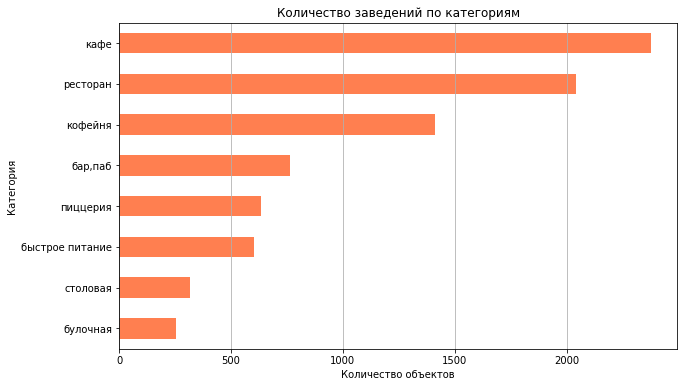

In [26]:
# строим горизонтальную столбчатую диаграмму с распределением количества заведений по категориям
df_unique['category'].value_counts().plot(
    kind='barh',
    title='Количество заведений по категориям',
    legend=False,
    rot=0,
    color='coral',
    figsize=(10, 6)
)
plt.xlabel('Количество объектов')
plt.ylabel('Категория')
plt.grid(axis='x')
plt.gca().invert_yaxis()

plt.show()

Основные категории представленные на рынке — кафе (2 376), рестораны (2 042) и кофейни (1 413): на них приходится большая часть рынка общественного питания.

Остальные категории заметно уступают: бары/пабы, пиццерии и быстрое питание — средний уровень представленности; столовые и булочные — наименее массовые сегменты.

---

### Задача 2

Исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводим подходящими визуализациями.

In [27]:
# выводим представленные округа и их количество
df_unique['district'].value_counts()

Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

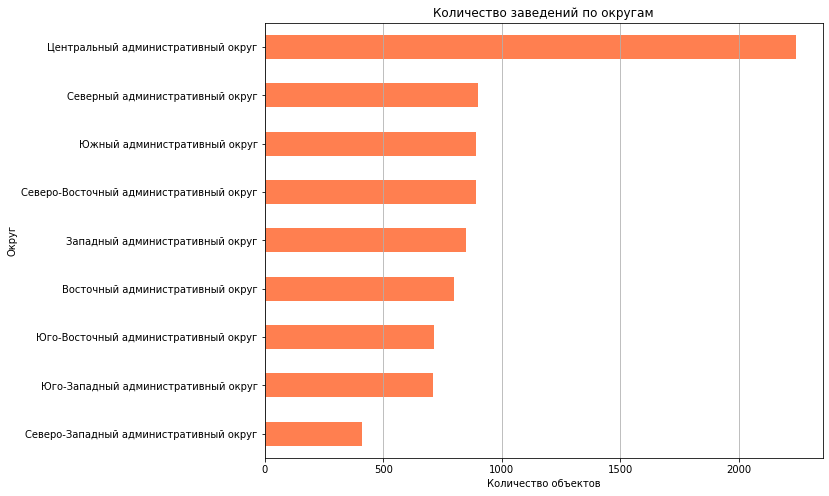

In [28]:
# строим горизонтальную столбчатую диаграмму с распределением округов
df_unique['district'].value_counts().plot(
    kind='barh',
    title='Количество заведений по округам',
    legend=False,
    rot=0,
    color='coral',
    figsize=(10, 8)
)
plt.xlabel('Количество объектов')
plt.ylabel('Округ')
plt.grid(axis='x')
plt.gca().invert_yaxis()

plt.show()

In [29]:
# выведем представленные в ЦАО заведения и их количество
cao = df_unique[df_unique['district'] == 'Центральный административный округ']
cao_category_counts = cao['category'].value_counts()
cao_category_counts

ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

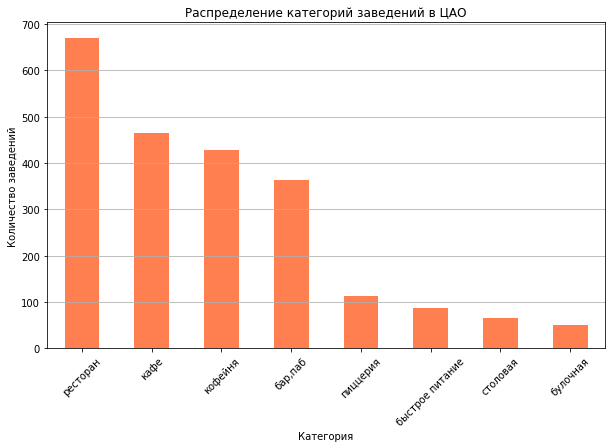

In [30]:
# строим столбчатую диаграмму с распределением категорий заведений в ЦАО
cao_category_counts.plot(
    kind='bar',
    title='Распределение категорий заведений в ЦАО',
    legend=False,
    rot=45,
    color='coral',
    figsize=(10, 6)
)

plt.xlabel('Категория')
plt.ylabel('Количество заведений')
plt.grid(axis='y')

plt.show()

По административным округам:
- ЦАО — абсолютный лидер по количеству заведений: в нём сосредоточено 2 242 точки — это заметно больше, чем в любом другом округе.
- Распределение по округам неравномерное: разрыв между ЦАО и остальными округами очень большой. Это говорит о высокой концентрации общепита в центре — из‑за трафика, туристической и деловой активности.
- Остальные округа сопоставимы между собой. Заметно от всех отстает СЗАО.

По категориям в ЦАО:

Структура заведений в ЦАО чётко отражает его специфику — это зона досуга, вечерней жизни и туристического трафика:
- Рестораны (670) — абсолютные лидеры, высокая доля говорит о спросе на формат 'выходного ужина', деловых обедов и особых случаев.
- Кафе (464) и кофейни (428) — уверенно держат вторую и третью позицию, востребованы как для коротких встреч, так и для работы вне дома, плюс хорошо вписываются в пешеходные потоки центра.
- Бары и пабы (364) — заметный сегмент, который подчёркивает активную вечернюю и ночную жизнь ЦАО, это места для неформального отдыха и тусовок.
- Остальные форматы (пиццерии — 113, быстрое питание — 87, столовые — 66, булочные — 50) — в сумме занимают существенно меньшую долю. В условиях высокой аренды и аудитории, ориентированной на досуг, массовые и бюджетные сегменты здесь менее конкурентоспособны.

---

### Задача 3

Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуем данные, ответим на вопросы и построим необходимые визуализации.

In [31]:
# количество сетевых и несетевых заведений 0 - несетевое, 1 - сетевое
df_unique['chain'].value_counts()

0    5199
1    3203
Name: chain, dtype: int64

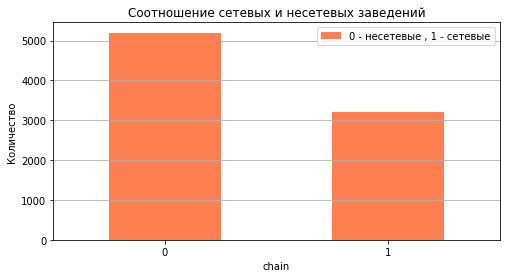

In [32]:
# строим столбчатую диаграмму распределения сетевых/несетевых заведений
df_unique['chain'].value_counts().plot(
    kind='bar',
    rot=0,
    color='coral',
    figsize=(8, 4)
)
plt.title('Соотношение сетевых и несетевых заведений')
plt.xlabel('chain')
plt.ylabel('Количество')
plt.legend(['0 - несетевые , 1 - сетевые'])
plt.grid(axis='y')

plt.show()

In [33]:
# распределение количества сетевых/несетевых заведений
df_unique.groupby(['category', 'chain'])['chain'].count()

category         chain
бар,паб          0         596
                 1         168
булочная         0          99
                 1         157
быстрое питание  0         371
                 1         232
кафе             0        1597
                 1         779
кофейня          0         693
                 1         720
пиццерия         0         303
                 1         330
ресторан         0        1313
                 1         729
столовая         0         227
                 1          88
Name: chain, dtype: int64

In [34]:
# доля сетевых заведений по категориям в процентах
chain_by_category = (
    df_unique
    .groupby('category')['chain'].mean()                
    .sort_values(ascending=False).mul(100)               
)
chain_by_category

category
булочная           61.328125
пиццерия           52.132701
кофейня            50.955414
быстрое питание    38.474295
ресторан           35.700294
кафе               32.786195
столовая           27.936508
бар,паб            21.989529
Name: chain, dtype: float64

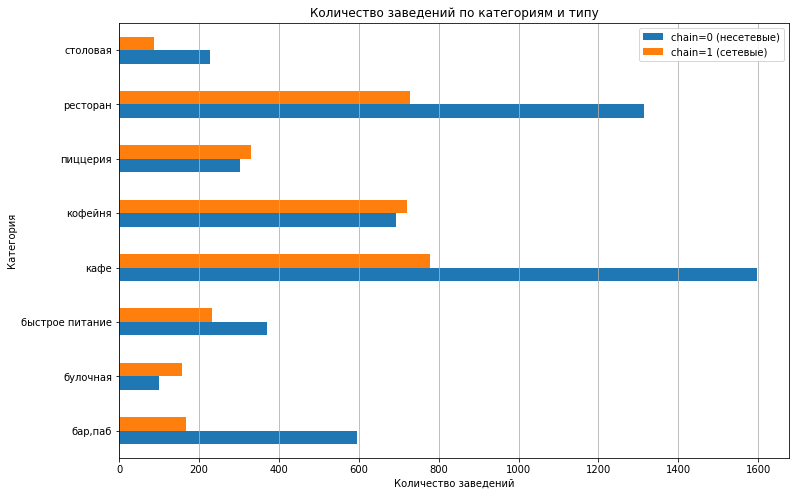

In [35]:
# строим горизонтальную столбчатую диаграмму с распределением сетевых/несетевых заведений по категориям
plot_data = (
    df_unique
    .groupby(['category', 'chain'])
    .size()
    .unstack(fill_value=0)
)

plot_data.plot(
    kind='barh',
    figsize=(12, 8),
)

plt.title('Количество заведений по категориям и типу')
plt.xlabel('Количество заведений')
plt.ylabel('Категория')
plt.legend(['chain=0 (несетевые)', 'chain=1 (сетевые)'])
plt.grid(axis='x')

plt.show()

- Рынок в основном состоит из несетевых заведений: количество несетевых точек достигает 5199 объектов, тогда как сетевых 3203 объекта.

- Только в трёх сегментах сетевые форматы занимают более половины рынка:
булочные — 61%;
пиццерии — 52%;
кофейни — 51%.

- В остальных категориях преобладают несетевые заведения: доля сетевых не превышает 36% ресторанов и опускается до 22% в сегменте баров и пабов. Такая картина объясняется разной логикой бизнеса: булочные и пиццерии выигрывают за счёт масштабов и единых стандартов, тогда как рестораны, кафе и бары делают ставку на уникальность концепции и локальную привлекательность.

---

### Задача 4

Исследуем количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведем для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


- Выведем информацию по полю seats, в анализе учавствует только 43% всех записей, поскольку установить даже приблизительное колличество посадочных мест не представляется возможным, а заполнять медианой или средним значением будет означать исказить статистику.

In [36]:
# выведем информацию по полю seats в разрезе категорий
stats = (
    df_unique
    .groupby('category')['seats']
    .describe()
)
stats

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",467.0,124.477516,145.162278,0.0,48.0,82.0,148.5,1288.0
булочная,148.0,89.385135,97.685844,0.0,25.0,50.0,120.0,625.0
быстрое питание,349.0,98.891117,106.611739,0.0,28.0,65.0,140.0,1040.0
кафе,1217.0,97.365653,117.922464,0.0,35.0,60.0,120.0,1288.0
кофейня,751.0,111.199734,127.837772,0.0,40.0,80.0,144.0,1288.0
пиццерия,427.0,94.496487,112.282703,0.0,30.0,55.0,120.0,1288.0
ресторан,1269.0,121.892041,123.792216,0.0,48.0,86.0,150.0,1288.0
столовая,164.0,99.750000,122.951453,0.0,40.0,75.5,117.0,1200.0


- Как видно выбросы встречаются в различных заведениях и максимальное количество посадочных мест явно не соответствует реальному. Возможно это показатели заглушки, либо общее пространство фуд корта, не относящееся к конкретному заведению. Также в каждой категории заведений встречается минимальное значение равное 0.

In [37]:
# вычисляем 99 процентиль
proc = df_unique['seats'].quantile(0.99)
print(f"99-й процентиль = {proc}")

99-й процентиль = 625.0


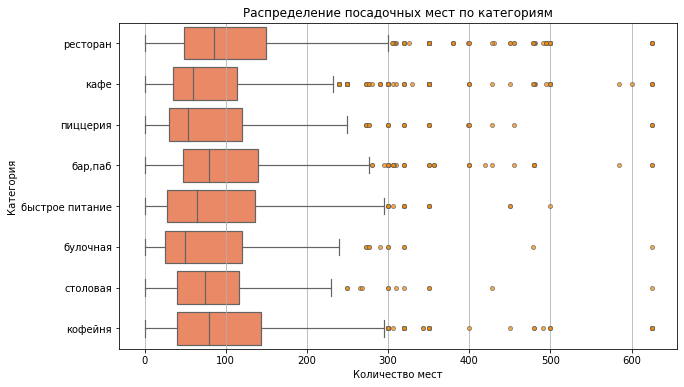

In [38]:
# построим визуализацию boxplot по категориям без учета значений выходящих за 99 процентиль
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_unique[df_unique['seats'] <= proc].dropna(subset=['seats']),
    y='category',
    x='seats',
    color='coral',
    linewidth=1.2,
    flierprops=dict(marker='o', markerfacecolor='darkorange', markersize=4, alpha=0.7)
)
plt.title(f'Распределение посадочных мест по категориям')
plt.xlabel('Количество мест')
plt.ylabel('Категория')
plt.grid(axis='x')

plt.show()

- Оставим единый порог выбросов в 300 посадочных мест и исключим заведения с количеством посадочных мест равных 0 и проанализируем полученные результаты

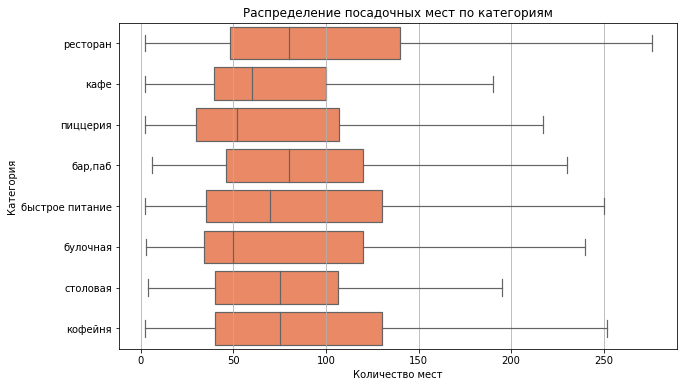

In [39]:
threshold_max = 300
threshold_min = 1

mask = (
    df_unique['seats'].notna() &
    (df_unique['seats'] > threshold_min) &
    (df_unique['seats'] <= threshold_max)
)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_unique[mask],
    y='category',
    x='seats',
    color='coral',
    linewidth=1.2,
    showfliers=False  
)
plt.title('Распределение посадочных мест по категориям')
plt.xlabel('Количество мест')
plt.ylabel('Категория')
plt.grid(axis='x')

plt.show()

In [40]:
# выведем статистические показатели посадочных мест по категориям
threshold_max = 300
threshold_min = 1  

stats_clean = (
    df_unique
    .dropna(subset=['seats'])
    .query('seats > @threshold_min and seats <= @threshold_max')
    .groupby('category')['seats']
    .describe()
)
stats_clean.round(1)

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",428.0,94.1,66.3,6.0,45.8,80.0,120.0,300.0
булочная,133.0,86.4,76.3,3.0,34.0,50.0,120.0,300.0
быстрое питание,314.0,90.5,76.7,2.0,35.0,70.0,130.0,300.0
кафе,1116.0,81.3,65.5,2.0,39.8,60.0,100.0,300.0
кофейня,687.0,92.8,72.5,2.0,40.0,75.0,130.0,300.0
пиццерия,399.0,81.2,69.7,2.0,30.0,52.0,107.0,300.0
ресторан,1172.0,101.0,69.5,2.0,48.0,80.0,140.0,300.0
столовая,152.0,84.1,61.2,4.0,40.0,75.0,106.2,300.0


- При изучении данных о количестве посадочных мест сразу бросаются в глаза два вида нестыковок.

Первый — это очень большие числа вроде 1288 или 1040. Скорее всего, это не отдельные кафе или рестораны, а вместимость целых фуд‑зон или торговых центров. Чтобы не искажать картину, такие значения были отсечены по порогу 99‑го перцентиля 625 мест — этого достаточно, чтобы убрать системные заглушки, не затрагивая реальные крупные заведения.

Второй тип аномалий — нули. Заведение с 0 посадочных мест в контексте этой задачи выглядит как техническая запись. Поэтому в финальный анализ вошли только объекты с положительным числом мест.

Даже после очистки остаются единичные крупные объекты (до 300 мест). Это не ошибки, а реальные форматы — например, большие столовые, банкетные залы или рестораны в ТЦ. Они формально считаются выбросами, но не ломают выводы. Опираемся на медиану, которая устойчива к таким редким точкам.

- Что можно считать типичным по категориям:

Столовые обычно рассчитаны на 75 человек (половина всех столовых — в диапазоне 40–106 мест).

Рестораны и бары/пабы — в среднем по 80 посадочных мест (48–140 и 46–120).

Кофейни — 75 мест (40–130).

Кафе — 60 мест (40–100).

Быстрое питание — 70 мест (35–130).

Пиццерии — 52 места (30–107).

Булочные — 50 мест (34–120).

- Тот факт, что среднее везде выше медианы, говорит о «длинном правом хвосте» в каждом сегменте: в любой категории есть заметная доля более крупных заведений, которые увеличивают среднее, но не меняют типичную картину.

---

### Задача 5

Исследуем рейтинг заведений. Визуализируем распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [41]:
# выведем статистические показатели рейтинга заведений
df_unique['rating'].describe()

count    8402.000000
mean        4.230017
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

In [42]:
df_unique.groupby('category')['rating'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",764.0,4.387696,0.380392,1.1,4.3,4.4,4.6,5.0
булочная,256.0,4.268359,0.386303,1.3,4.2,4.3,4.4,5.0
быстрое питание,603.0,4.050249,0.560949,1.1,3.9,4.2,4.3,5.0
кафе,2376.0,4.124285,0.566001,1.0,4.0,4.2,4.4,5.0
кофейня,1413.0,4.277282,0.372250,1.4,4.1,4.3,4.4,5.0
пиццерия,633.0,4.301264,0.336162,1.0,4.2,4.3,4.4,5.0
ресторан,2042.0,4.290402,0.413143,1.0,4.2,4.3,4.5,5.0
столовая,315.0,4.211429,0.454205,1.0,4.1,4.3,4.4,5.0


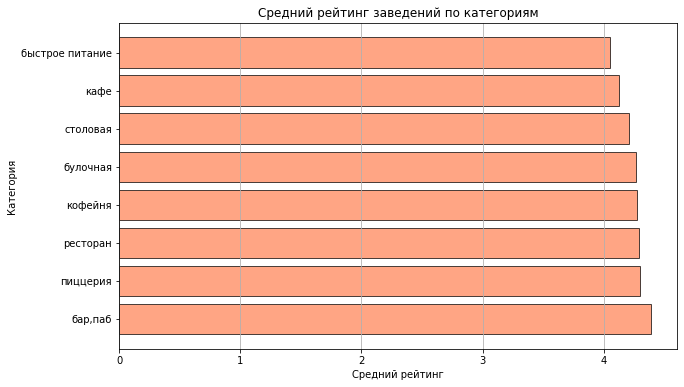

In [43]:
# построим горизонтальную столбчатую диаграмму со средним рейтингом по категориям
avg_ratings = (
    df_unique.groupby('category')['rating']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))
plt.barh(avg_ratings['category'], avg_ratings['rating'], color='coral', alpha=0.7, edgecolor='black')
plt.title('Средний рейтинг заведений по категориям')
plt.xlabel('Средний рейтинг')
plt.ylabel('Категория')
plt.grid(axis='x')

plt.show()

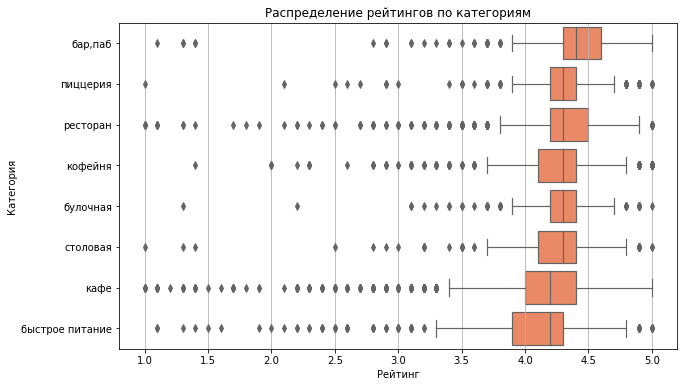

In [44]:
# построим визуализацию размаха среднего рейтинга
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_unique,
    y='category',
    x='rating',
    order=avg_ratings['category'].tolist(),
    color='coral',
    linewidth=1.2,
    showfliers=True
)

plt.title('Распределение рейтингов по категориям')
plt.xlabel('Рейтинг')
plt.ylabel('Категория')
plt.grid(axis='x')

plt.show()

- На диаграмме размаха во всех категориях заметен выраженный левый хвост распределения — это говорит о наличии доли заведений с заметно более низкими оценками. При этом медианные значения рейтингов близки, 4.2–4.3, а различия в средних рейтингах от 4.39 у «бар,паб» до 4.05 у «быстрое питание» в основном обусловлены разной выраженностью этого хвоста: в одних сегментах низкие оценки встречаются реже и слабее тянут среднее, в других — чаще и сильнее. 
- Таким образом, различия между категориями умеренные и объясняются скорее неоднородностью качества внутри сегмента, чем принципиально разным уровнем сервиса.

---

### Задача 6

Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений. Построим и визуализируем матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберем самую сильную связь и проверим её.

In [45]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df_unique[['category', 'district', 'chain', 'seats', 'price',
                         'is_24_7', 'rating']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['chain', 'seats', 'rating']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.281253
district,0.200761
category,0.189716
is_24_7,0.150365
chain,0.107833
seats,0.000000


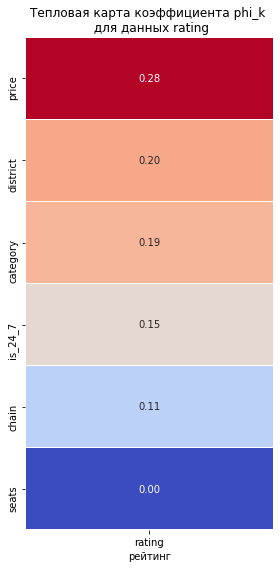

In [46]:
# Строим тепловую карту
plt.figure(figsize=(4, 8))

# Сохраняем матрицу корреляции признака rating с другими признаками клиента
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            linewidths=0.5, 
            cbar=False 
)
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('рейтинг')
plt.tight_layout()

plt.show()

In [47]:
# выведем статистические показатели rating с групировкой по price
df_unique.groupby('price')['rating'].agg(['count', 'mean', 'std']).sort_values('mean', ascending=False)

,count,mean,std
price,,,
высокие,478,4.436611,0.314197
выше среднего,564,4.386348,0.223507
средние,2117,4.297874,0.295653
низкие,156,4.173077,0.372671
unknown,5087,4.166778,0.545209


- В ходе анализа взаимосвязей рейтинга с различными характеристиками заведений с помощью коэффициента Phik была определена наиболее выраженная зависимость — между рейтингом и ценовой категорией (Phik = 0.28). При этом важно отметить, что данная величина отражает лишь умеренную связь: она не свидетельствует о жёсткой детерминированности рейтинга ценой, но указывает на наличие систематического тренда.
- Проверка тренда через сравнение средних рейтингов по ценовым сегментам подтвердила его устойчивость: наблюдается последовательное снижение среднего рейтинга по мере перехода от более дорогих сегментов к более дешёвым. Так, заведения категории `высокие` имеют средний рейтинг 4.44, тогда как категории `низкие` и `unknown`(они же пропуски) — около 4.17 (разница порядка 0.27 балла).
- Категория `unknown`, составляющая более 60 % выборки, характеризуется наибольшим разбросом оценок (std = 0.55), что говорит о поляризации мнений клиентов: отсутствие явной ценовой маркировки не позволяет сформировать у посетителей единый ожидаемый уровень сервиса.
- Таким образом, ценовая категория выступает в качестве наиболее информативного предиктора рейтинга среди рассмотренных факторов, она позволяет объяснить часть систематической вариации оценок, хотя и не определяет рейтинг однозначно.

---

### Задача 7

Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве. Для них посчитаем значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводим подходящими визуализациями.

In [48]:
# выведем топ 15 сетевых заведений по поставленноё задаче
top_chains = (
    df_unique[df_unique['chain'] == 1]
    .groupby('name')
    .agg(
        count=('id', 'count'),
        avg_rating=('rating', 'mean'),
        category=('category', 'first')
    )
    .reset_index()
    .sort_values('count', ascending=False)
    .head(15)
)

top_chains[['name', 'count', 'avg_rating', 'category']]

,name,count,avg_rating,category
746,Шоколадница,120,4.177500,кофейня
344,Домино'с Пицца,76,4.169737,пиццерия
340,Додо Пицца,74,4.286486,пиццерия
148,One Price Coffee,71,4.064789,кофейня
759,Яндекс Лавка,69,3.872464,ресторан
59,Cofix,65,4.075385,кофейня
170,Prime,50,4.116000,ресторан
679,Хинкальная,44,4.322727,быстрое питание
378,КОФЕПОРТ,42,4.147619,кофейня
431,Кулинарная лавка братьев Караваевых,39,4.394872,кафе


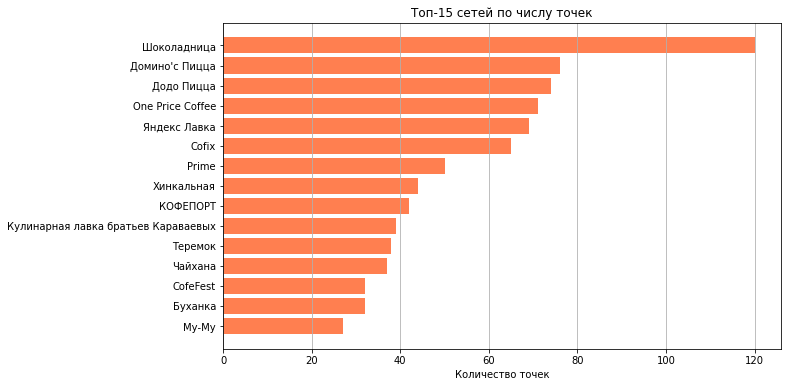

In [49]:
# построим горизонтальную столбчатую диаграмму с количеством заведений
plt.figure(figsize=(10, 6))

plt.barh(top_chains['name'], 
         top_chains['count'], 
         color='coral'
)
plt.xlabel('Количество точек')
plt.title('Топ‑15 сетей по числу точек')
plt.gca().invert_yaxis()
plt.grid(axis='x')

plt.show()

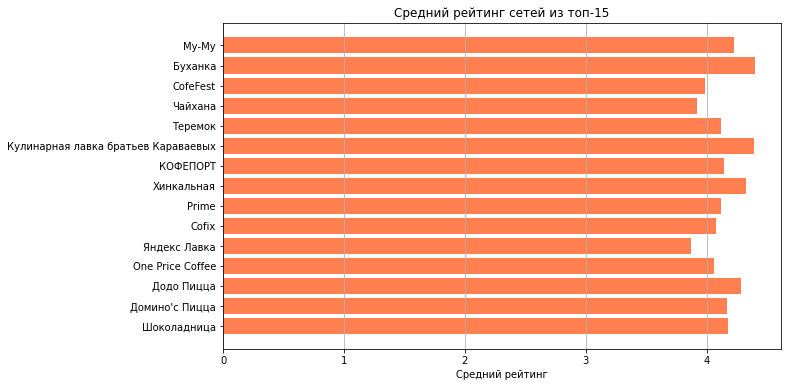

In [50]:
#  построим горизонтальную столбчатую диаграмму со средним рейтингом заведений
plt.figure(figsize=(10, 6))

plt.barh(top_chains['name'], 
         top_chains['avg_rating'], 
         color='coral'
)
plt.xlabel('Средний рейтинг')
plt.title('Средний рейтинг сетей из топ‑15')
plt.grid(axis='x')

plt.show()

- Лидер по масштабу — 'Шоколадница': у неё заметно больше точек, чем у ближайших конкурентов (120 против 76 у 'Домино’с Пицца'). 
- Лучшие по рейтингу — небольшие и средние сети: самые высокие оценки у 'Буханки' 4.397 и 'Кулинарной лавки братьев Караваевых' 4.395. При этом у абсолютного лидера по количеству точек 'Шоколадница' рейтинг средний - 4.178. Получается, масштаб не гарантирует самый высокий рейтинг.
- Категории в топе - кофейни доминируют: в топ‑15 сразу 5 кофейных сетей (Шоколадница, One Price Coffee, Cofix, КОФЕПОРТ, CofeFest) — это треть списка. Также заметно представлены кафе и рестораны.
- Есть разброс по качеству: самый низкий рейтинг в топе — у 'Яндекс Лавки' - 3.872), самый высокий — у 'Буханки' - 4.397. Разница почти в 0.5 балла — это ощутимый разрыв на шкале оценок.

---

### Задача 8

Изучим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируем цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводим подходящими визуализациями.


- На этапе предобработки данных, чтобы не искажать показатели, мы оставили столбец `middle_avg_bill` с пропусками. Теперь для выполнения данной задачи, частично(насколько это возможно) заполним пропуски в поле и проведем сравнительный анализ. 

In [51]:
# создаем датафрейм и заполняем пропуски в нем по паре name, district
df_fill = df_unique.copy()

median_by_name_district = df_fill.groupby(['name', 'district'])['middle_avg_bill'].transform('median')

df_fill['middle_avg_bill_net_dist'] = df_fill['middle_avg_bill'].fillna(median_by_name_district)

# Считаем, сколько удалось заполнить
before = df_fill['middle_avg_bill'].isna().sum()
after = df_fill['middle_avg_bill_net_dist'].isna().sum()
print(f"Было пропусков: {before:,}")
print(f"Стало пропусков: {after:,}")
print(f"Заполнено: {before - after:,} строк")


Было пропусков: 5,253
Стало пропусков: 4,648
Заполнено: 605 строк


In [52]:
# выводим реальные данные (без заполнения)
stats_real = (
    df_unique
    .dropna(subset=['middle_avg_bill'])
    .groupby('district')['middle_avg_bill']
    .agg(avg_real='mean', median_real='median')
)
# данные с частичным заполнением по (name, district)
stats_filled = (
    df_fill
    .groupby('district')['middle_avg_bill_net_dist']
    .agg(avg_filled='mean', median_filled='median')
)

comparison = stats_real.join(stats_filled).reset_index()

comparison['diff_avg'] = comparison['avg_filled'] - comparison['avg_real']

# Сортируем по среднему чеку в варианте с заполнением (чтобы видеть итоговую картину)
comparison = comparison.sort_values('avg_filled', ascending=False)

comparison[['district', 'avg_real', 'avg_filled', 'diff_avg', 'median_real', 'median_filled']]

,district,avg_real,avg_filled,diff_avg,median_real,median_filled
8,Южный административный округ,834.398089,1643.292244,808.894155,500.0,500.0
5,Центральный административный округ,1191.057547,1121.312248,-69.745299,1000.0,1000.0
1,Западный административный округ,1053.225490,986.286269,-66.939221,1000.0,750.0
2,Северный административный округ,927.959627,841.579897,-86.379730,650.0,600.0
4,Северо-Западный административный округ,822.222930,802.002890,-20.220040,700.0,700.0
0,Восточный административный округ,820.626923,789.674772,-30.952151,575.0,500.0
7,Юго-Западный административный округ,792.561702,733.690813,-58.870889,600.0,550.0
3,Северо-Восточный административный округ,716.611296,690.324484,-26.286812,500.0,500.0
6,Юго-Восточный административный округ,654.097938,584.606299,-69.491639,450.0,400.0


---


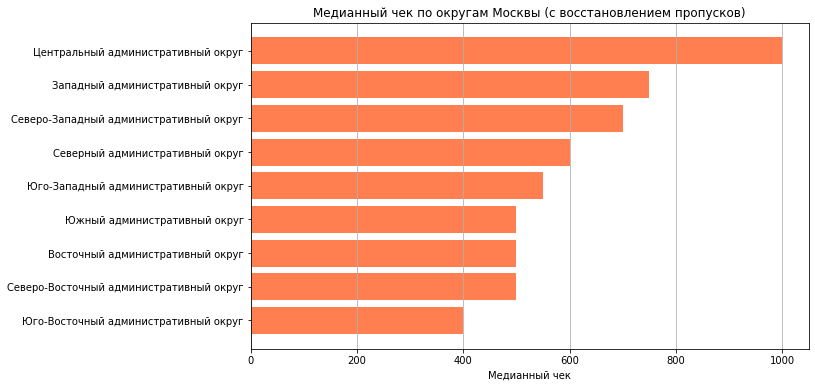

In [53]:
# строим горизонтальную столбчатую диаграму медианы цен по округам
plot_data = comparison.sort_values('median_filled', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(plot_data['district'], plot_data['median_filled'], color='coral') 

plt.xlabel('Медианный чек')
plt.title('Медианный чек по округам Москвы (с восстановлением пропусков)')
plt.gca().invert_yaxis()  
plt.grid(axis='x')

plt.show()

- Вариация среднего чека по округам выражена чётко, но качество исходной выборки неоднородно.
- ЦАО демонстрирует стабильно высокий уровень цен: медианный чек — 1000 это обычная цена заведения в центре. Дальше идёт плавное снижение: чем дальше от центра, тем ниже типичная цена. Средний чек снижается с 1191 до 1121. Это говорит о хорошей представительности выборки в центре: добавление бюджетных точек сетей лишь немного скорректировало среднее, не меняя типичную высокую цену.
- ЮАО — ключевое исключение: исходный средний чек 834 сильно занижен относительно восстановленного 1643, разница — +809. При этом медиана остаётся на уровне 500, что указывает на асимметрию выборки: в исходных данных преобладали бюджетные заведения, а дорогие форматы не попали в расчёт из‑за особенностей извлечения данных.
- В остальных округах частичное заполнение пропусков медианой по паре 'сеть + район' привело к умеренному снижению среднего чека (на 20–87), что отражает добавление более бюджетных точек тех же сетей.
- Таким образом, зональная закономерность («центр дороже, окраины дешевле») прослеживается и по реальным, и по восстановленным данным. 

Однако для объективной картины рынка необходимо учитывать сильное искажение выборки в ЮАО.

---

### Промежуточный вывод

Обобщим полученные результаты, выделив, самые важные.

Проведённый анализ показал, что рынок общественного питания Москвы имеет ярко выраженную пространственно‑экономическую структуру, в которой тесно переплетаются география, формат заведения и ценовая политика.

Ключевой закономерностью является центр‑периферийный градиент: в ЦАО концентрируется наибольшее количество заведений, здесь же фиксируются самые высокие цены и доминируют форматы, ориентированные на досуг (рестораны, бары, кафе). По мере удаления от центра снижается и плотность точек, и средний уровень цен — эта зональность устойчива, но её корректное выявление оказалось возможным только после детальной предобработки данных.

Особую роль в достоверности выводов сыграла работа с качеством данных. Выбросы по вместимости, нулевые значения и систематические пропуски в ценах могли существенно исказить картину: например, без восстановления пропусков цены в отдельных округах (в первую очередь в ЮАО) выглядели заниженными. Применение устойчивых метрик (медианы вместо среднего) и целевых правил очистки (отсечение экстремальных перцентилей, фильтрация нулей) позволило отделить реальные рыночные тренды от артефактов данных.

Рынок остаётся преимущественно локальным и несетевым, хотя в отдельных сегментах (булочные, пиццерии, кофейни) сетевые игроки успешно масштабируются за счёт стандартизации. При этом масштаб сети не гарантирует более высокий рейтинг: лучшие оценки характерны для небольших и средних заведений, а восприятие качества в целом умеренно связано с ценовой категорией.

Таким образом, исследовательский анализ подтвердил, что основные драйверы различий на рынке — это местоположение, формат и ценовая позиция заведения, а не просто размер или сетевая принадлежность. При этом любые количественные выводы о рынке критически зависят от корректной обработки пропусков и выбросов: без этого даже очевидные закономерности (вроде 'центр дороже') могут быть неверно оценены или вовсе пропущены.

<a id='4razd'></a>
## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.

##### 1. Общий обзор работы
В проекте выполнен полный цикл анализа данных об общепите Москвы: загружены и изучены датасеты rest_df и price_df, проведена предобработка (удаление дубликатов с нормализацией названий и адресов, работа с пропусками, отсечение выбросов по вместимости), оптимизированы типы данных для экономии памяти. Для устойчивых выводов активно применялась медиана и целевые правила восстановления пропусков (в т. ч. по паре «сеть + район»).


##### 2. Главные выводы
Рынок структурирован по принципу 'центр — периферия': в ЦАО — максимальная концентрация заведений - 2 242 точки и самые высокие цены (медианный чек — 1 000р.); по мере удаления от центра плотность точек и уровень цен устойчиво снижаются. При этом без восстановления пропусков картина по округам (особенно по ЮАО) существенно искажается.

Формат и локация определяют нишу: в центре доминируют досуговые форматы (рестораны, кофейни, кафе и бары), бюджетные сегменты там менее конкурентоспособны. Типичная вместимость заведений — 50–80 мест; для корректной оценки важно использовать медиану из‑за «длинного хвоста» крупных объектов.

Преобладают несетевые заведения (5 199 против 3 203 сетевых). Сетевая модель эффективна в стандартизируемых сегментах (булочные, пиццерии, кофейни), а в сегментах с упором на уникальность (рестораны, бары) рынок остаётся локальным.

Масштаб не гарантирует высокий рейтинг: лидер по числу точек ('Шоколадница', 120 заведений) имеет средний рейтинг (4.178), тогда как небольшие сети ('Буханка', 'Кулинарная лавка братьев Караваевых') — самые высокие оценки.

Ценовая категория — ключевой фактор рейтинга (Phik = 0.28): рейтинг систематически снижается от дорогих сегментов к дешёвым. 

##### 3. Рекомендации
Локацию стоит выбирать с учётом зонального распределения спроса: центр подходит для заведений премиального и досугового формата, а спальные районы — для бюджетных и ориентированных на повседневные визиты.

Для аналитики лучше использовать метрики, устойчивые к выбросам (вроде медианы), а при работе с пропусками — фиксировать методику и отдельно помечать районы, где данные могут быть искажены (как в случае с ЮАО).

При развитии сети учитывать специфику сегмента: масштабирование хорошо ложится на булочные, пиццерии и кофейни, а в ресторанах и барах важнее не количество точек, а проработанная, самобытная концепция.

Ценовое позиционирование должно быть прозрачным: чёткое обозначение ценовой ниши помогает клиентам правильно оценивать ожидания от заведения и снижает разброс отзывов из‑за несовпадения ожиданий и реальности.